# Teil 2

Das ist eine einfache Bearbeitung von Teil 2 mit dem Datensatz `churn_modelling.csv`.
Ich schaue mir zuerst die Daten an und prüfe danach Statistik, Kategorien, eine Grafik und eine Skalierung.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

file_path = 'churn_modelling.csv'
df = pd.read_csv(file_path)

print('Zeilen und Spalten:', df.shape)
df.head()


Zeilen und Spalten: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Erster Überblick

Hier zeige ich die Spalten, Datentypen und fehlende Werte. So sieht man schnell, ob der Datensatz Probleme hat.


In [2]:
print('Spalten:')
print(df.columns.tolist())

print('\nDatentypen:')
print(df.dtypes)

print('\nFehlende Werte:')
print(df.isna().sum())


Spalten:
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Datentypen:
RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Fehlende Werte:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


## 2.1 Zielfeld

Ich wähle `Exited` als Zielfeld. Dort sieht man, ob ein Kunde bei der Bank bleibt (`0`) oder kündigt (`1`). Das ist gut für ein Klassifikationsmodell, weil man später genau diese Entscheidung vorhersagen möchte.


In [3]:
df['Exited'].value_counts()


Exited
0    7963
1    2037
Name: count, dtype: int64

## 2.2 Statistische Informationen

Für numerische Felder berechne ich Mittelwert, Median, Standardabweichung, Minimum und Maximum.


In [4]:
numerische_spalten = df.select_dtypes(include='number').columns

statistik = pd.DataFrame({
    'Mittelwert': df[numerische_spalten].mean(),
    'Median': df[numerische_spalten].median(),
    'Standardabweichung': df[numerische_spalten].std(),
    'Minimum': df[numerische_spalten].min(),
    'Maximum': df[numerische_spalten].max()
})

statistik.round(2)


,Mittelwert,Median,Standardabweichung,Minimum,Maximum
RowNumber,5000.50,5000.50,2886.90,1.00,10000.00
CustomerId,15690940.57,15690738.00,71936.19,15565701.00,15815690.00
CreditScore,650.53,652.00,96.65,350.00,850.00
Age,38.92,37.00,10.49,18.00,92.00
Tenure,5.01,5.00,2.89,0.00,10.00
Balance,76485.89,97198.54,62397.41,0.00,250898.09
NumOfProducts,1.53,1.00,0.58,1.00,4.00
HasCrCard,0.71,1.00,0.46,0.00,1.00
IsActiveMember,0.52,1.00,0.50,0.00,1.00
EstimatedSalary,100090.24,100193.92,57510.49,11.58,199992.48


## Kategorische Felder

Für Textfelder schaue ich einfache Häufigkeiten an. Im Datensatz sind `Surname`, `Geography` und `Gender` Textfelder. `Surname` ist für das spätere Modell nicht so sinnvoll, aber für die Datenbeschreibung zeige ich es kurz trotzdem.

In [5]:
text_spalten = df.select_dtypes(include='object').columns

for spalte in text_spalten:
    print(spalte + ':')
    print('Verschiedene Werte:', df[spalte].nunique())
    print(df[spalte].value_counts().head(10))
    print()

Surname:
Verschiedene Werte: 2932
Surname
Smith       32
Scott       29
Martin      29
Walker      28
Brown       26
Genovese    25
Yeh         25
Shih        25
Wright      24
Maclean     24
Name: count, dtype: int64

Geography:
Verschiedene Werte: 3
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Gender:
Verschiedene Werte: 2
Gender
Male      5457
Female    4543
Name: count, dtype: int64



## 2.3 Grafik

Die Grafik zeigt die Kündigungsrate pro Land. So kann man schnell sehen, in welchem Land mehr Kunden kündigen.


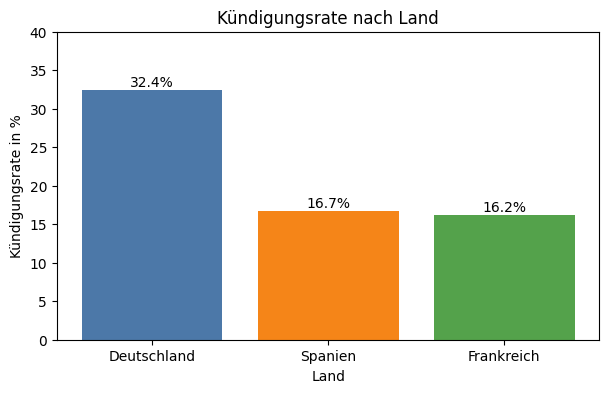

In [6]:
kuendigungen_land = df.groupby('Geography')['Exited'].mean() * 100
kuendigungen_land = kuendigungen_land.sort_values(ascending=False)

land_namen = {
    'France': 'Frankreich',
    'Germany': 'Deutschland',
    'Spain': 'Spanien'
}
labels = [land_namen.get(land, land) for land in kuendigungen_land.index]

plt.figure(figsize=(7, 4))
plt.bar(labels, kuendigungen_land.values, color=['#4c78a8', '#f58518', '#54a24b'])
plt.title('Kündigungsrate nach Land')
plt.xlabel('Land')
plt.ylabel('Kündigungsrate in %')
plt.ylim(0, 40)

for i, value in enumerate(kuendigungen_land.values):
    plt.text(i, value + 0.5, str(round(value, 1)) + '%', ha='center')

plt.show()


## 2.4 Skalierung

Ich skaliere das Feld `Balance` mit `StandardScaler`. Skalierung kann bei Machine Learning hilfreich sein, weil grosse Zahlen sonst stärker wirken können als kleine Zahlen. Nach der Skalierung liegt der Mittelwert ungefähr bei 0 und die Standardabweichung bei 1.


In [7]:
scaler = StandardScaler()
df['Balance_scaled'] = scaler.fit_transform(df[['Balance']])

df[['Balance', 'Balance_scaled']].head(10)


,Balance,Balance_scaled
0,0.00,-1.225848
1,83807.86,0.117350
2,159660.80,1.333053
3,0.00,-1.225848
4,125510.82,0.785728
5,113755.78,0.597329
6,0.00,-1.225848
7,115046.74,0.618019
8,142051.07,1.050820
9,134603.88,0.931463


In [8]:
print('Mittelwert skaliert:', round(df['Balance_scaled'].mean(), 4))
print('Standardabweichung skaliert:', round(df['Balance_scaled'].std(), 4))


Mittelwert skaliert: -0.0
Standardabweichung skaliert: 1.0001


## Kurzfazit

Das Zielfeld ist `Exited`. Der Datensatz hat 10'000 Zeilen, keine fehlenden Werte und enthält numerische sowie kategoriale Felder. Besonders interessant sind zum Beispiel `Age`, `Balance`, `NumOfProducts`, `IsActiveMember`, `Geography` und `Gender`. Mit der Grafik und der Skalierung ist der Datensatz gut für ein einfaches ML-Modell vorbereitet.
